# AV-PedAware multimodal visualization

Visualize paired audio, RGB image, depth image, and lidar samples generated under `data/pairs/`.

In [9]:
from pathlib import Path

import cv2
import numpy as np
from scipy.io import wavfile

try:
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise ImportError('matplotlib is required for image/audio visualization') from exc

try:
    import open3d as o3d
except ImportError as exc:
    raise ImportError('open3d is required for lidar visualization') from exc

PAIRS_ROOT = Path('data/pairs')
bag_name = 'rosbag2_2026_05_17-09_34_07'
sample_id = '0001'

sample_root = PAIRS_ROOT / bag_name
assert sample_root.exists(), f'Bag directory not found: {sample_root}'

In [10]:
def load_sample(root, sample):
    audio_rate, audio = wavfile.read(root / 'audio' / f'{sample}.wav')
    image_bgr = cv2.imread(str(root / 'image' / f'{sample}.png'), cv2.IMREAD_COLOR)
    depth = cv2.imread(str(root / 'depth' / f'{sample}.png'), cv2.IMREAD_UNCHANGED)
    lidar = np.fromfile(root / 'lidar' / f'{sample}.bin', dtype=np.float32).reshape(-1, 4)

    if image_bgr is None:
        raise FileNotFoundError(f'RGB image not found for sample {sample}')
    if depth is None:
        raise FileNotFoundError(f'Depth image not found for sample {sample}')

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    return audio_rate, audio, image_rgb, depth, lidar


def show_modalities(root, sample):
    audio_rate, audio, image_rgb, depth, lidar = load_sample(root, sample)
    time_axis = np.arange(len(audio)) / audio_rate

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(time_axis, audio)
    axes[0].set_title(f'Audio waveform ({audio.shape[1] if audio.ndim > 1 else 1} channels)')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(alpha=0.25)

    axes[1].imshow(image_rgb)
    axes[1].set_title('RGB image')
    axes[1].axis('off')

    depth_view = np.ma.masked_equal(depth, 0)
    depth_plot = axes[2].imshow(depth_view, cmap='viridis')
    axes[2].set_title('Depth image')
    axes[2].axis('off')
    fig.colorbar(depth_plot, ax=axes[2], fraction=0.046, pad=0.04)

    fig.suptitle(f'{root.name} / sample {sample} / lidar points: {len(lidar):,}')
    fig.tight_layout()
    plt.show()


def show_lidar_open3d(root, sample, point_size=1.5):
    _, _, _, _, lidar = load_sample(root, sample)
    if lidar.size == 0:
        raise ValueError(f'No lidar points found for sample {sample}')

    points = lidar[:, :3]
    intensity = lidar[:, 3]
    intensity = (intensity - intensity.min()) / max(float(np.ptp(intensity)), 1e-6)
    colors = plt.cm.viridis(intensity)[:, :3]

    cloud = o3d.geometry.PointCloud()
    cloud.points = o3d.utility.Vector3dVector(points)
    cloud.colors = o3d.utility.Vector3dVector(colors)

    vis = o3d.visualization.Visualizer()
    vis.create_window(window_name=f'Lidar {root.name} / {sample}', width=1280, height=720)
    vis.add_geometry(cloud)
    render = vis.get_render_option()
    render.point_size = point_size
    render.background_color = np.asarray([0.02, 0.02, 0.02])
    vis.run()
    vis.destroy_window()

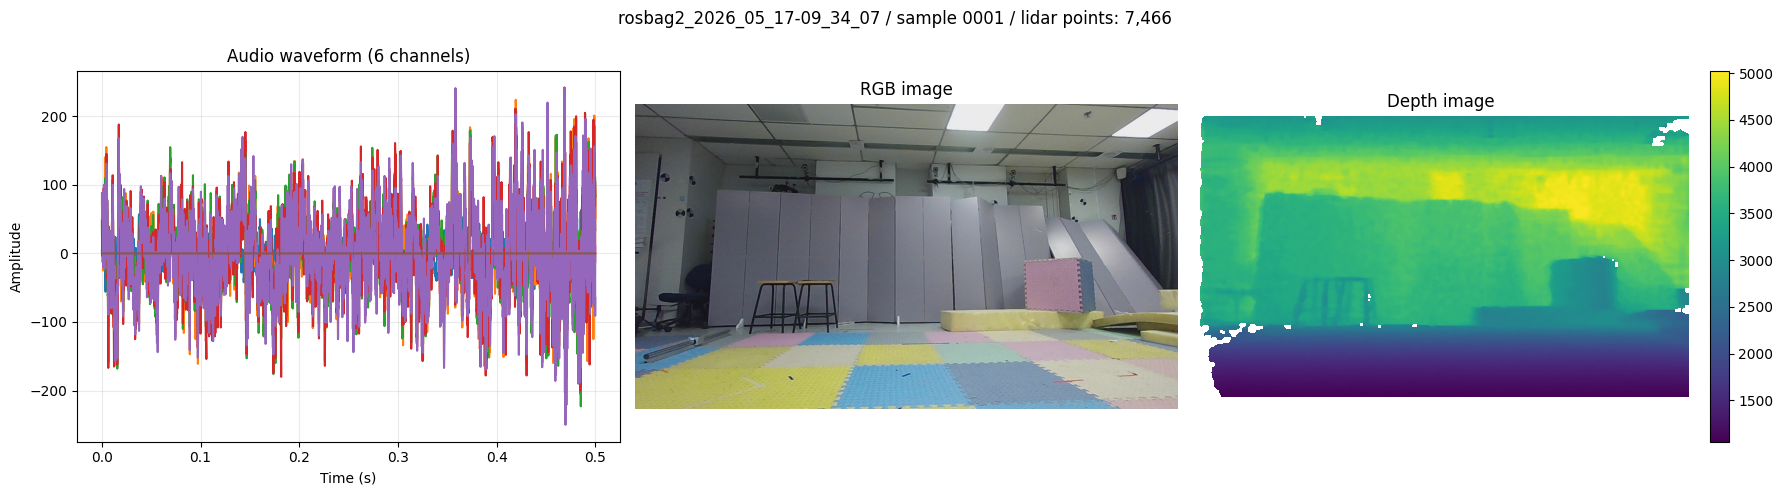

In [11]:
show_modalities(sample_root, sample_id)

In [12]:
show_lidar_open3d(sample_root, sample_id)